In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

In [3]:
df = pd.read_csv(r"C:\Users\stuti\Downloads\ds learning\data.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [5]:
print(df.shape)

(541909, 8)


In [6]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [7]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [8]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.dropna(subset="Description")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
df_with_customer = df.dropna(subset=["CustomerID"]).copy()
df_with_customer["CustomerID"] = df_with_customer["CustomerID"].astype(int)
print(df_with_customer)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0        1

In [12]:
df.duplicated().count()

np.int64(541909)

In [13]:
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").sum()
df["IsCancelled"]

0         9288
1         9288
2         9288
3         9288
4         9288
          ... 
541904    9288
541905    9288
541906    9288
541907    9288
541908    9288
Name: IsCancelled, Length: 541909, dtype: int64

In [14]:
df_clean = df[
    (~df["IsCancelled"]) &
    (df["Quantity" ] > 0) &
    (df["UnitPrice"] > 0) 
    ].copy()

df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,9288
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,9288
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,9288
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,9288
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,9288
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,9288
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,9288


In [15]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], format="%m/%d/%Y %H:%M")
df_clean["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 530104, dtype: datetime64[ns]

In [16]:
df_clean["TotalPrice"] = np.multiply(df_clean["Quantity"], df_clean["UnitPrice"])
df_clean["TotalPrice"]

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 530104, dtype: float64

In [17]:
print("Data Cleaned")
print("OG rows : " , df.shape[0], "| Cleaned rows : ", df_clean.shape[0])
print("Cancelled orders removed:" , df["IsCancelled"].sum())
print(df_clean[["InvoiceNo", "Quantity" , "UnitPrice" , "TotalPrice", "InvoiceDate"]].head())

Data Cleaned
OG rows :  541909 | Cleaned rows :  530104
Cancelled orders removed: 5033250792
  InvoiceNo  Quantity  UnitPrice  TotalPrice         InvoiceDate
0    536365         6       2.55       15.30 2010-12-01 08:26:00
1    536365         6       3.39       20.34 2010-12-01 08:26:00
2    536365         8       2.75       22.00 2010-12-01 08:26:00
3    536365         6       3.39       20.34 2010-12-01 08:26:00
4    536365         6       3.39       20.34 2010-12-01 08:26:00


In [18]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
df_clean["Minute"] = df_clean["InvoiceDate"].dt.minute
df_clean["Dayofweek"] = df_clean["InvoiceDate"].dt.dayofweek
print(df_clean[["Year", "Month", "Day", "Hour", "Minute", "Dayofweek"]].head(10))


   Year  Month  Day  Hour  Minute  Dayofweek
0  2010     12    1     8      26          2
1  2010     12    1     8      26          2
2  2010     12    1     8      26          2
3  2010     12    1     8      26          2
4  2010     12    1     8      26          2
5  2010     12    1     8      26          2
6  2010     12    1     8      26          2
7  2010     12    1     8      28          2
8  2010     12    1     8      28          2
9  2010     12    1     8      34          2


In [19]:
df_clean["Year"]

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
541904    2011
541905    2011
541906    2011
541907    2011
541908    2011
Name: Year, Length: 530104, dtype: int32

In [20]:
#np.sum() adds all values in the  "TotalPrice"
total_revenue = np.sum(df_clean["TotalPrice"])
#nunique counts unique InvoiceNo values
total_orders = df_clean["InvoiceNo"].nunique()
#nunique counts distinct CustomerID values
total_customers = df_clean["CustomerID"].nunique()
#cal the avg order value
#df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean() first computes total spend per invoice, then averages those invoice totals.
avg_order_value = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean()

In [21]:
print("Key metrics")
print(f"Total Revenue : ${total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Total Unique Customers: {total_customers}")
print(f"Average Order Value :  ${avg_order_value :,.2f}")
print("\n")

Key metrics
Total Revenue : $10,666,684.54
Total Unique Orders: 19960
Total Unique Customers: 4338
Average Order Value :  $534.40




In [22]:
#TOP PRODUCTS (by Revenue and by Quantity)
top_products_revenue = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

top_products_qty = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

print("STEP 6: Top 10 Products by Revenue")
print(top_products_revenue)
print("\n")
print("Top 10 Products by Quantity sold")
print(top_products_qty)

STEP 6: Top 10 Products by Revenue
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalPrice, dtype: float64


Top 10 Products by Quantity sold
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    307

In [23]:
#STEP 7: Country wise analysis
country_revenue = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .astype(int)
    .sort_values(ascending = False)
)

print("Revenue by Country(Top 10)")
print(country_revenue.head(10))

Revenue by Country(Top 10)
Country
United Kingdom    9025222
Netherlands        285446
EIRE               283453
Germany            228867
France             209715
Australia          138521
Spain               61577
Switzerland         57089
Belgium             41196
Sweden              38378
Name: TotalPrice, dtype: int64


In [24]:
#STEP 7: Country wise analysis
country_revenue = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .astype(int)
    .sort_values(ascending = False)
)

print("Revenue by Country(Top 10)")
print(country_revenue.head(10))

Revenue by Country(Top 10)
Country
United Kingdom    9025222
Netherlands        285446
EIRE               283453
Germany            228867
France             209715
Australia          138521
Spain               61577
Switzerland         57089
Belgium             41196
Sweden              38378
Name: TotalPrice, dtype: int64


In [25]:
# Yearly Sales Trend
df_clean["Year"] = df_clean["InvoiceDate"].dt.to_period("Y")
yearly_sales = df_clean.groupby("Year")["TotalPrice"].sum()
print("\nYearly Revenue Trend:")
print(yearly_sales)


Yearly Revenue Trend:
Year
2010     823746.140
2011    9842938.404
Freq: Y-DEC, Name: TotalPrice, dtype: float64


In [26]:
# Monthly Sales Trend
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")
monthly_sales = df_clean.groupby("YearMonth")["TotalPrice"].sum()
print("Monthly Revenue Trend:")
print(monthly_sales)


Monthly Revenue Trend:
YearMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: TotalPrice, dtype: float64


In [27]:
# Daily Sales Trend
df_clean["Day"] = df_clean["InvoiceDate"].dt.to_period("D")
daily_sales = df_clean.groupby("Day")["TotalPrice"].sum()
print("\nDaily Revenue Trend:")
print(daily_sales)


Daily Revenue Trend:
Day
2010-12-01     58960.79
2010-12-02     47748.38
2010-12-03     46943.71
2010-12-05     31774.95
2010-12-06     54830.46
                ...    
2011-12-05     88741.96
2011-12-06     56713.21
2011-12-07     75439.16
2011-12-08     82495.00
2011-12-09    200920.60
Freq: D, Name: TotalPrice, Length: 305, dtype: float64


In [28]:
#STEP 9: Customer Analysis(RFM Style)
customer_summary = df_clean.groupby("CustomerID").agg(
    TotalSpent = ("TotalPrice", "sum"),
    NumOrders = ("InvoiceNo", "nunique"),
    AvgOrderValue = ("TotalPrice", "mean"),
    LastPurchase = ("InvoiceDate", "max"),
).sort_values("TotalSpent", ascending=False)
print( "Top 5 Customers by Total Spend" )
print(customer_summary.head(5))

Top 5 Customers by Total Spend
            TotalSpent  NumOrders  AvgOrderValue        LastPurchase
CustomerID                                                          
14646.0      280206.02         73     134.973998 2011-12-08 12:12:00
18102.0      259657.30         60     602.453132 2011-12-09 11:50:00
17450.0      194550.79         46     577.302047 2011-12-01 13:29:00
16446.0      168472.50          2   56157.500000 2011-12-09 09:15:00
14911.0      143825.06        201      25.343623 2011-12-08 15:54:00


In [29]:
#Step 10: Numpy based statistical analysis on order values
order_values = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().values
order_values

array([  139.12,    22.2 ,   278.73, ...,   339.2 ,   249.45, 11062.06],
      shape=(19960,))

In [30]:
print("Order Value Statistics (Numpy)")
print("Mean:", np.mean(order_values))
print("Median:", np.median(order_values))
print("Standard Deviation :", np.std(order_values))
print("Minimum:" ,np.min(order_values))
print("Maximum:", np.max(order_values))
print("25th percentile:", np.percentile(order_values,25))
print("75th percentile:", np.percentile(order_values,75))


Order Value Statistics (Numpy)
Mean: 534.403033266533
Median: 303.83500000000004
Standard Deviation : 1780.4430456461234
Minimum: 0.38
Maximum: 168469.6
25th percentile: 152.51
75th percentile: 495.615


In [31]:
df_clean.to_csv("cleaned_ecommerce_data.csv", index=False)
customer_summary.to_csv("customer_summary.csv")
country_revenue.to_csv("country_revenue.csv")

In [33]:
# STEP 12: Data Visualization

# Set a clean, consistent visual style for all charts
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Set a default figure size so charts aren't cramped
plt.rcParams["figure.figsize"] = (10, 6)

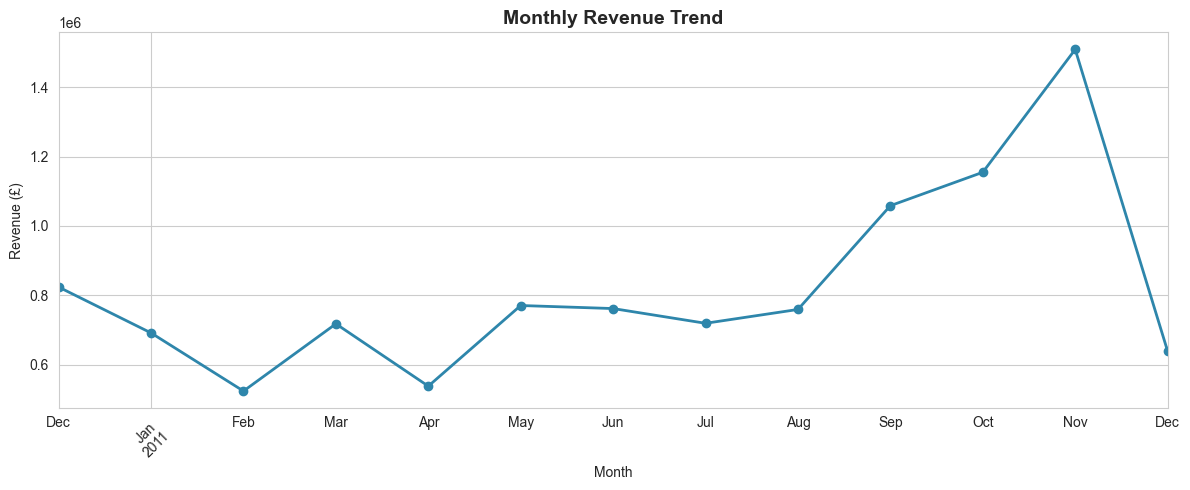

In [34]:
# 12.1: Monthly Revenue Trend

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o", color="#2E86AB", linewidth=2)

plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png", dpi=150)
plt.show()

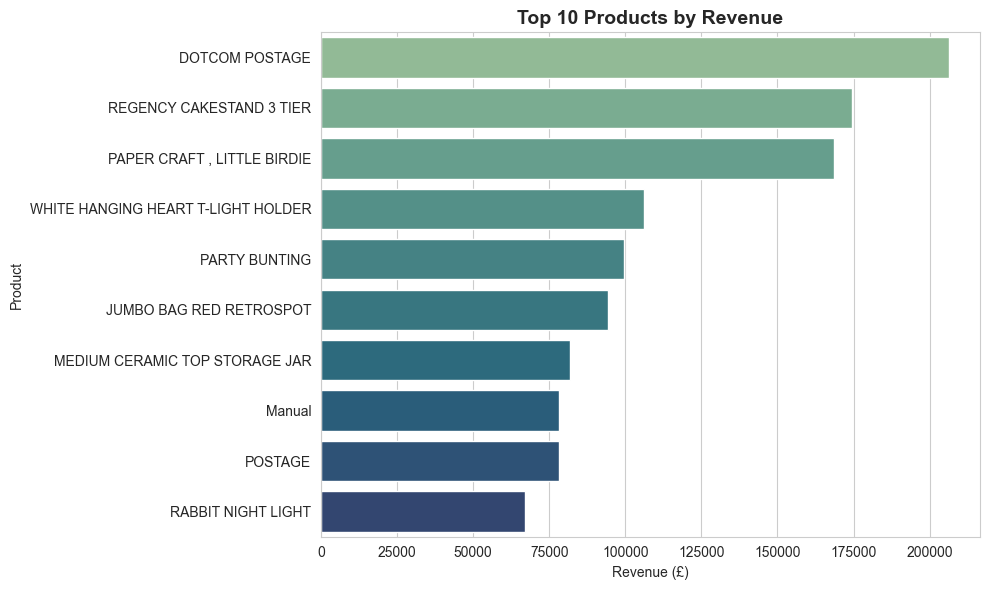

In [35]:
# 12.2: Top 10 Products by Revenue

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_products_revenue.values,
    y=top_products_revenue.index,
    hue=top_products_revenue.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products_revenue.png", dpi=150)
plt.show()

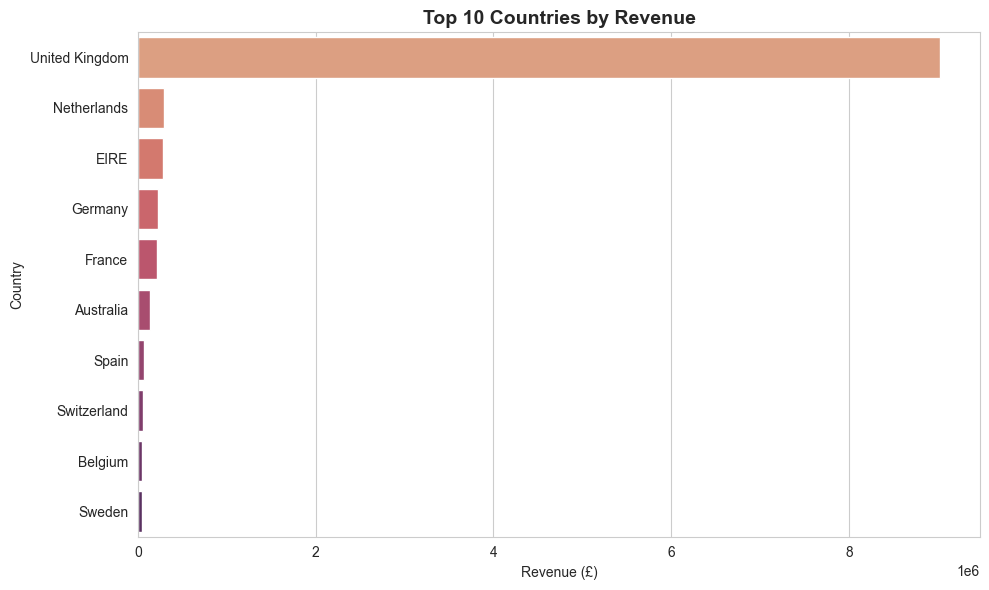

In [36]:
# 12.3: Top 10 Countries by Revenue 

top_countries = country_revenue.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="flare",
    legend=False
)

plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=150)
plt.show()

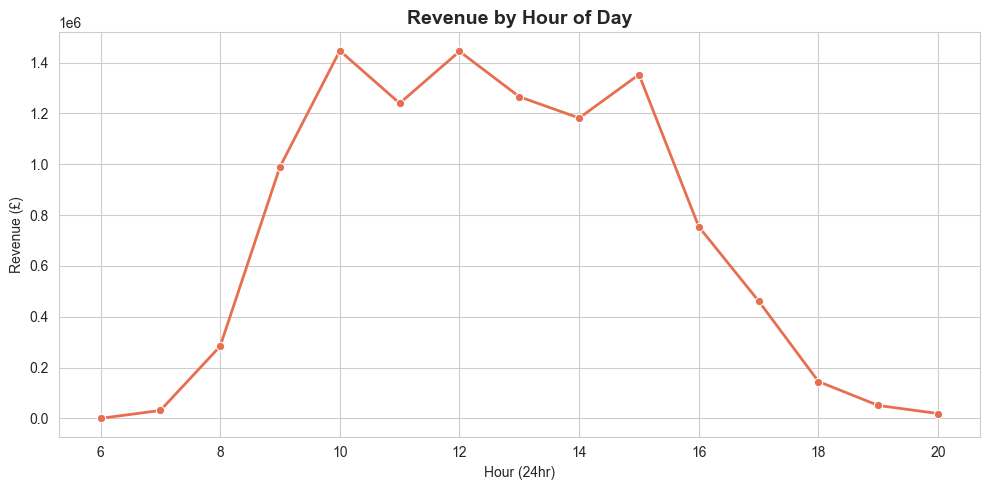

In [37]:
# 12.4: Revenue by Hour of Day

revenue_by_hour = df_clean.groupby("Hour")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(x=revenue_by_hour.index, y=revenue_by_hour.values, marker="o", color="#E76F51", linewidth=2)

plt.title("Revenue by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour (24hr)")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("revenue_by_hour.png", dpi=150)
plt.show()

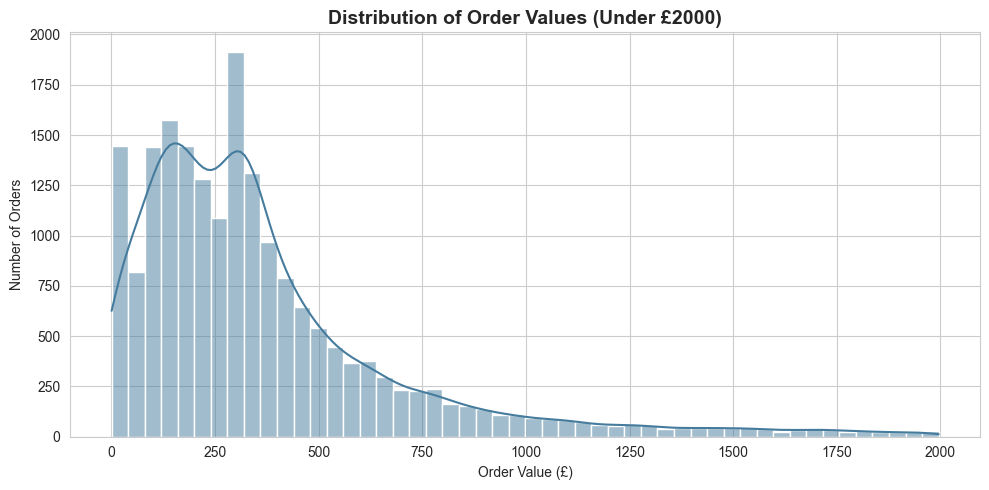

In [38]:
# 12.5: Distribution of Order Values

plt.figure(figsize=(10, 5))
sns.histplot(order_values[order_values < 2000], bins=50, color="#457B9D", kde=True)

plt.title("Distribution of Order Values (Under £2000)", fontsize=14, fontweight="bold")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("distribution_order_values.png", dpi=150)
plt.show()

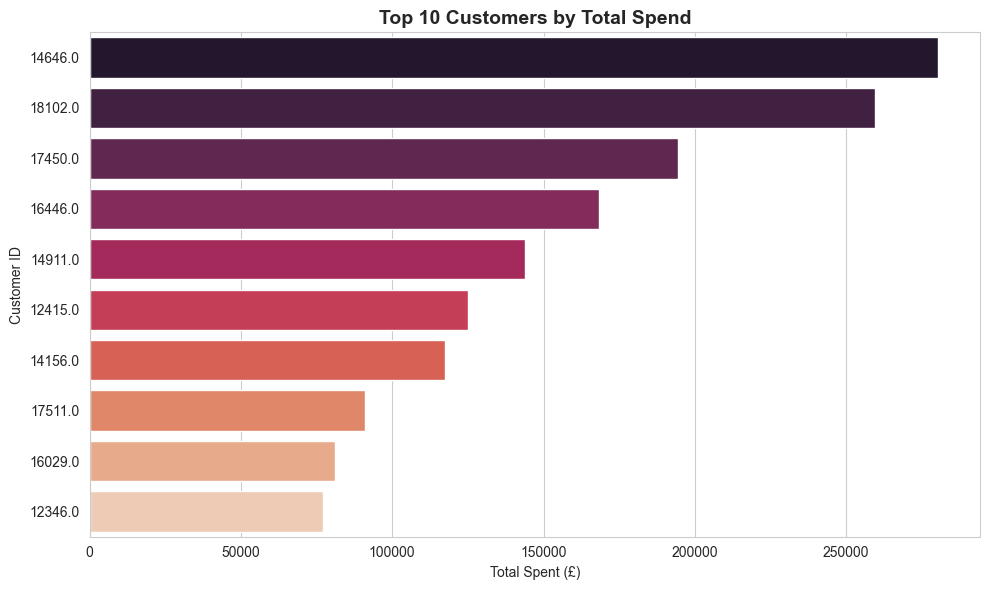

In [39]:
# 12.6: Top 10 Customers by Total Spend

top_customers = customer_summary.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_customers["TotalSpent"],
    y=top_customers.index.astype(str),
    hue=top_customers.index.astype(str),
    palette="rocket",
    legend=False
)

plt.title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")
plt.xlabel("Total Spent (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("top_customers_totspend.png", dpi=150)
plt.show()

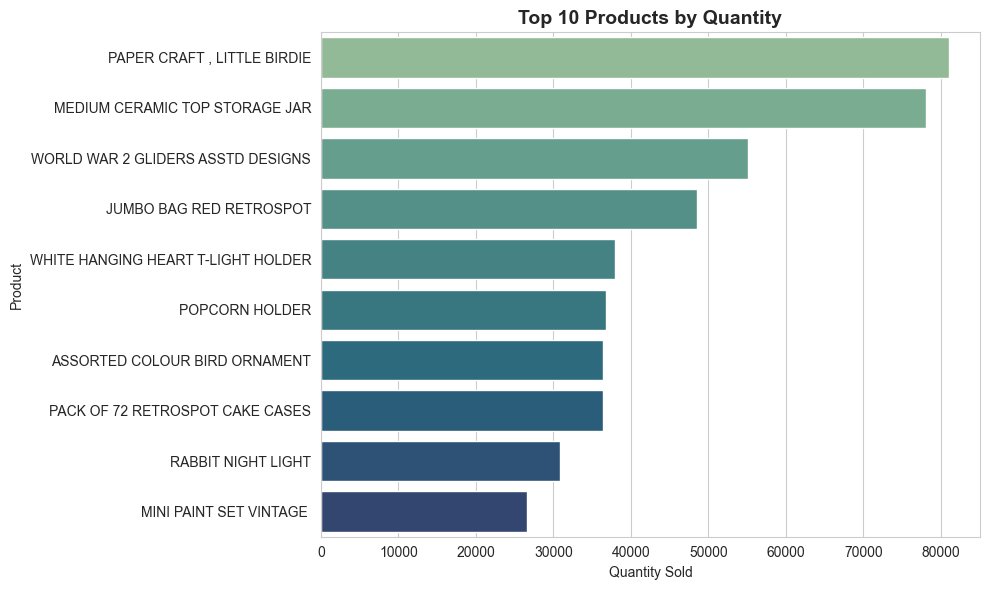

In [40]:
# 12.7: Top 10 Products by Quantity

plt.figure()
sns.barplot(
    x=top_products_qty.values,
    y=top_products_qty.index,
    hue=top_products_qty.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Products by Quantity", fontsize=14, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products_quantity.png", dpi=150)
plt.show()

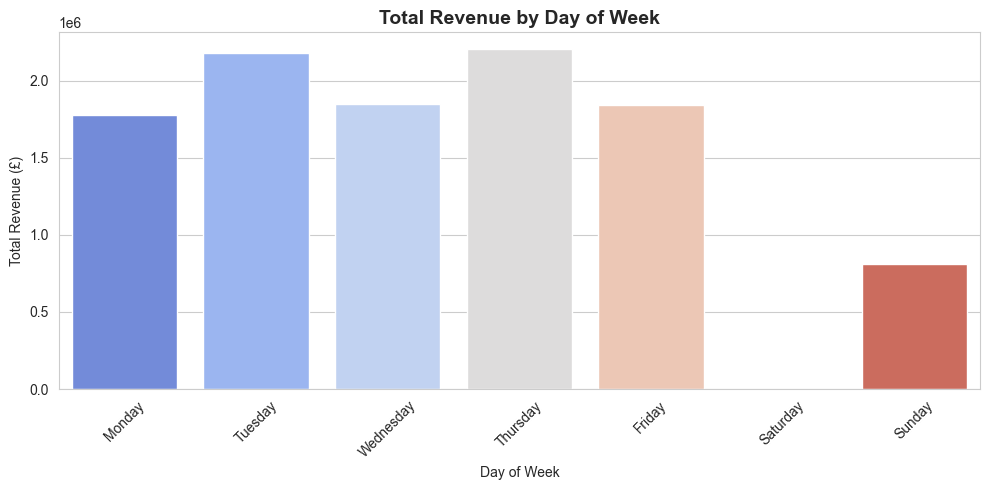

In [41]:
# 12.8: Sales by Day of Week (Bar Chart)
# ---------------------------------------------------------
day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df_clean["Dayofweek"] = df_clean["Dayofweek"].map(day_map)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

sales_by_day = (
    df_clean.groupby("Dayofweek")["TotalPrice"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values,
    hue=sales_by_day.index,
    palette="coolwarm",
    legend=False
)
plt.title("Total Revenue by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_by_dayofweek.png", dpi=150)
plt.show()

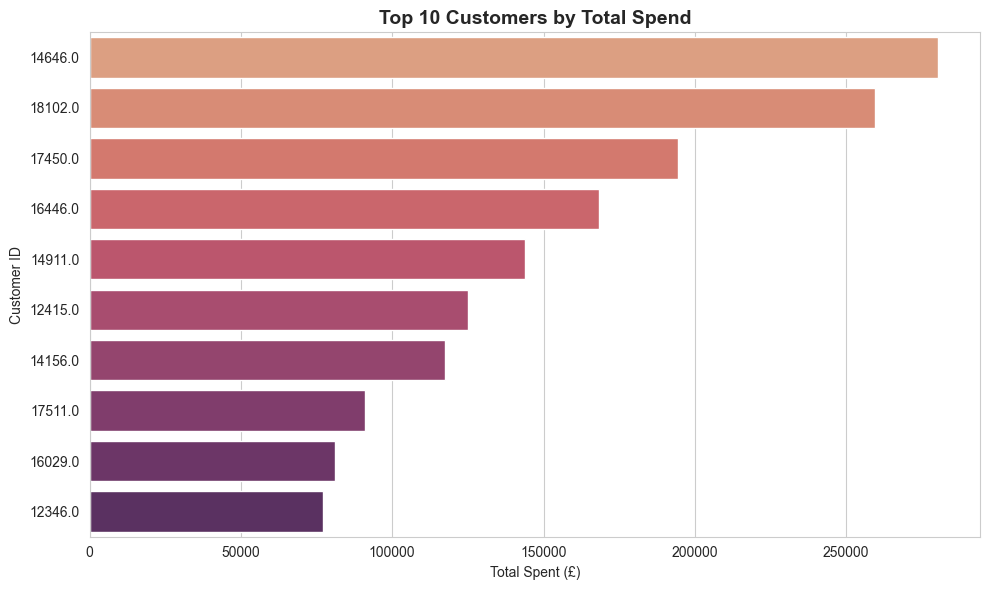

In [42]:
# 12.9: Top 10 Customers by Total Spend (Bar Chart)
# ---------------------------------------------------------
top_customers = customer_summary.head(10)
 
plt.figure()
sns.barplot(
    x=top_customers["TotalSpent"].values,
    y=top_customers.index.astype(str),
    hue=top_customers.index.astype(str),
    palette="flare"
)
plt.title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")
plt.xlabel("Total Spent (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("top_customers.png", dpi=150)
plt.show()

In [43]:
# 12.10: Correlation Heatmap (Quantity, UnitPrice, TotalPrice)
# ---------------------------------------------------------
plt.figure()
corr = df_clean[["Quantity", "UnitPrice", "TotalPrice"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=15
plt.show()
 
print("STEP 12: All visualizations created and saved as PNG files.")

SyntaxError: '(' was never closed (3248169672.py, line 8)

#STEP 13:LINEAR REGRESSION MODEL

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


In [45]:
ml_data = customer_summary[["NumOrders", "AvgOrderValue", "TotalSpent"]].dropna()

X= ml_data[["NumOrders", "AvgOrderValue"]]
y= ml_data["TotalSpent"]

print("Feature set shape:", X.shape)
print("Target shape:", y.shape)


Feature set shape: (4338, 2)
Target shape: (4338,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 3470
Test samples: 868


In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Intercept:", model.intercept_)
print("Coefficients (NumOrders, AvgOrderValue):", model.coef_)

Model trained successfully.
Intercept: -866.0268982425914
Coefficients (NumOrders, AvgOrderValue): [663.12854199   1.75090119]


In [51]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")       
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")    
print(f"R-squared (R2): {r2:.2f}")  


Model Evaluation Metrics:
Mean Absolute Error (MAE): 1259.25
Mean Squared Error (MSE): 11190136.49
Root Mean Squared Error (RMSE): 3345.17
R-squared (R2): 0.63


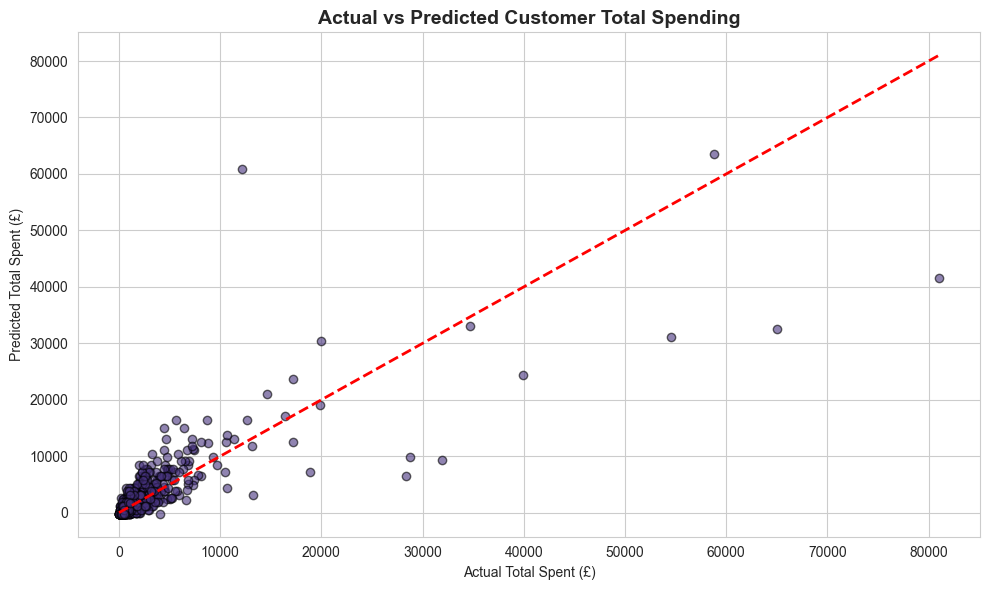

In [53]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Total Spent (£)")
plt.ylabel("Predicted Total Spent (£)")
plt.title("Actual vs Predicted Customer Total Spending", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
